# SBR+ convergence analysis

This example demonstrates how to perform a convergence study on SBR+ (Shooting and Bouncing Rays)
setup parameters to ensure accurate and reliable radar cross-section (RCS) results.

The Shooting and Bouncing Rays (SBR+) method is a high-frequency asymptotic technique used in HFSS
for electrically large problems such as antenna placement and radar cross-section (RCS) analysis.
Two key parameters affect solution accuracy:

- **Ray Density Per Wavelength**: Controls how many rays are launched per wavelength. Higher values
  provide more accurate results but increase computation time.
- **Maximum Number of Bounces**: Defines how many times rays can reflect off surfaces before terminating.
  More bounces capture multi-reflection effects but increase solve time.

This example systematically varies these parameters to identify converged settings where further
increases do not significantly change the RCS results. The workflow demonstrates best practices
for ensuring your SBR+ analysis is properly converged.

Keywords: **HFSS**, **SBR+**, **Radar cross-section**, **Convergence study**, **Ray tracing**.

## Prerequisites

### Perform imports

In [1]:
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
from ansys.aedt.core.examples.downloads import download_file
from ansys.aedt.core.hfss import Hfss


### Define constants
Constants help ensure consistency and avoid repetition throughout the example.

In [2]:
AEDT_VERSION = "2025.2"
NUM_CORES = 4
NG_MODE = False  # Open AEDT UI when it is launched.

### Create temporary directory

Create a temporary directory where downloaded data or
dumped data can be stored.
If you'd like to retrieve the project data for subsequent use,
the temporary folder name is given by ``temp_folder.name``.

In [3]:
temp_folder = tempfile.TemporaryDirectory(suffix=".ansys")

## Model preparation

### Download the model

The model used in this example will be downloaded from the
[example-data](https://github.com/ansys/example-data)
GitHub repository. The model is a trihedral corner reflector,
a common radar calibration target with well-known RCS characteristics.

In [4]:
project_path = download_file("sbr_convergence", "trihedral_rcs.aedt", temp_folder.name)

### Launch HFSS and open project

Launch HFSS and open the project containing the trihedral reflector geometry.

In [5]:
hfss = Hfss(
    project=project_path,
    version=AEDT_VERSION,
    non_graphical=NG_MODE,
    new_desktop=True,
)

PyAEDT INFO: Parsing C:\Users\ansys\AppData\Local\Temp\tmpsxolr6nj.ansys\pyaedt\sbr_convergence\trihedral_rcs.aedt.


PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 0.26.dev0.


PyAEDT INFO: Initializing new Desktop session.


PyAEDT INFO: AEDT version 2025.2.


...

PyAEDT WARNING: Service Pack is not detected. PyAEDT is currently connecting in Insecure Mode.


PyAEDT WARNING: Please download and install latest Service Pack to use connect to AEDT in Secure Mode.


PyAEDT INFO: Project trihedral_rcs has been opened.


PyAEDT INFO: Active Design set to HFSSDesign1


PyAEDT INFO: AEDT objects correctly read


## Convergence study parameters

### Setup parameters

Define the analysis frequency and convergence criteria.
The convergence threshold determines when two successive results
are considered "close enough" that further refinement is unnecessary.

In [6]:
setup_frequency = ["10GHz"]  # Analysis frequency
convergence_threshold = 0.5  # Maximum allowed change in dB (convergence criterion)

### Advanced SBR+ options

Configure advanced ray tracing options:

- **PDF (Physical Theory of Diffraction)**: Improves accuracy for diffraction effects at edges.
- **UTD (Uniform Theory of Diffraction)**: Adds rays to capture diffraction phenomena.

These options can improve accuracy but increase computation time.

In [7]:
enable_ptd = False
enable_utd = False

### Convergence methodology

Define how convergence is assessed:

- **Convergence Method**:
  - ``"average"``: Checks if the average RCS across all angles has converged.
  - ``"point_to_point"``: Checks if the maximum change at any single angle is below threshold (more stringent).

The workflow follows a natural progression:
1. First, converge the bounce number (how many reflections to track)
2. Then, converge the ray density (how many rays to launch)

In [8]:
convergence_method = "point_to_point"  # "average" or "point_to_point"

### Starting values

Define initial values for the convergence sweep.
The algorithm will increment these values until convergence is achieved.

In [9]:
starting_ray_density = 1
starting_bounce_number = 2
max_ray_density = 2
max_bounce_number = 5

### Configure PDF/UTD settings

Map the boolean flags to the appropriate HFSS setup string.

In [10]:
if enable_ptd and enable_utd:
    ptd_utd_setting = "PDF Correction + UTD Rays"
elif enable_ptd and not enable_utd:
    ptd_utd_setting = "PDF Correction"
elif not enable_ptd and enable_utd:
    ptd_utd_setting = "UTD Rays"
else:
    ptd_utd_setting = "None"

In [11]:
print(f"PDF: {enable_ptd}, UTD: {enable_utd} → Setting: '{ptd_utd_setting}'")
print(f"Convergence Method: {convergence_method}")

PDF: False, UTD: False → Setting: 'None'
Convergence Method: point_to_point


## The convergence story: A step-by-step workflow

In this section, we'll perform a convergence study by following a clear, sequential workflow.
The story unfolds in phases:

1. **Phase 1**: We start by testing different bounce numbers while keeping ray density fixed
2. **Phase 2**: Once we find a good bounce number, we test different ray densities
3. **Conclusion**: We identify the optimal settings that give us reliable RCS results

This approach mimics how an engineer would manually tune the parameters to achieve convergence.

In [12]:
print("=" * 70)
print("SBR+ CONVERGENCE STUDY - A Sequential Workflow Story")
print("=" * 70)
print(f"\nOur goal: Find SBR+ settings that give us accurate RCS results")
print(f"Convergence threshold: Changes must be < {convergence_threshold} dB")
print(f"PDF/UTD Setting: {ptd_utd_setting}")
print(f"Analysis frequency: {setup_frequency[0]}")

SBR+ CONVERGENCE STUDY - A Sequential Workflow Story

Our goal: Find SBR+ settings that give us accurate RCS results
Convergence threshold: Changes must be < 0.5 dB
PDF/UTD Setting: None
Analysis frequency: 10GHz


### Initialize data storage

We'll store all our results as we progress through the convergence study.

In [13]:
# Storage for bounce number convergence (Phase 1)
bounce_numbers = []
avg_rcs_bounce = []
all_rcs_bounce = []
all_phi_bounce = []

In [14]:
# Storage for ray density convergence (Phase 2)
ray_densities = []
avg_rcs_ray = []
all_rcs_ray = []
all_phi_ray = []

## Phase 1: Finding the right number of bounces

We begin by determining how many ray bounces are needed for accurate results.
We'll keep the ray density fixed at a reasonable starting value and gradually
increase the number of bounces until the RCS results stabilize.

In [15]:
print("\n" + "=" * 70)
print(f"PHASE 1: CONVERGING BOUNCE NUMBER")
print(f"(Ray Density fixed at {starting_ray_density})")
print("=" * 70)


PHASE 1: CONVERGING BOUNCE NUMBER
(Ray Density fixed at 1)


In [16]:
current_bounce = starting_bounce_number
previous_rcs_bounce = None
bounce_converged = False
converged_bounce_number = max_bounce_number  # Initialize with max value

In [17]:
while not bounce_converged and current_bounce <= max_bounce_number:

    print(f"\n--- Testing Bounce Number: {current_bounce} ---")

    # Delete any existing SBR setup to start fresh
    if "SBR" in hfss.setup_names:
        hfss.delete_setup("SBR")

    hfss.save_project()

    # Create a new SBR+ setup with current parameters
    setup1 = hfss.create_setup(name="SBR")
    setup1.props["RayDensityPerWavelength"] = starting_ray_density
    setup1.props["MaxNumberOfBounces"] = current_bounce
    setup1["RangeType"] = "SinglePoints"
    setup1["RangeStart"] = setup_frequency[0]
    setup1.props["ComputeFarFields"] = True
    setup1.props["PTDUTDSimulationSettings"] = ptd_utd_setting
    setup1.update()

    print(f"Setup created: Ray Density = {starting_ray_density}, Bounces = {current_bounce}")

    # Run the simulation
    hfss.analyze_setup("SBR", cores=NUM_CORES)
    print("Simulation complete. Retrieving RCS data...")

    # Extract RCS results
    sweep_names = hfss.existing_analysis_sweeps
    data = hfss.get_rcs_data(setup=sweep_names[0], expression="MonostaticRCSTotal")
    solution_data = data.get_monostatic_rcs()
    solution_data.primary_sweep = "IWavePhi"

    iwavephi_values = solution_data.primary_sweep_values
    rcs_values = solution_data.get_expression_data(formula="dB10")[1]
    average_rcs = np.mean(rcs_values)

    # Store the results
    bounce_numbers.append(current_bounce)
    avg_rcs_bounce.append(average_rcs)
    all_rcs_bounce.append(rcs_values.copy())
    all_phi_bounce.append(iwavephi_values.copy())

    print(f"Average RCS: {average_rcs:.4f} dBsm")

    # Check if we've converged (compare with previous iteration)
    if previous_rcs_bounce is not None:
        if convergence_method == "average":
            previous_avg = np.mean(previous_rcs_bounce)
            change = np.abs(average_rcs - previous_avg)
            print(f"Change from previous: {change:.4f} dB")

            if change < convergence_threshold:
                print(f"\n*** BOUNCE NUMBER CONVERGED at {current_bounce} bounces! ***")
                print(f"The RCS results are now stable (change < {convergence_threshold} dB)")
                bounce_converged = True
                converged_bounce_number = current_bounce
        else:  # point_to_point
            absolute_changes = np.abs(rcs_values - previous_rcs_bounce)
            max_change = np.max(absolute_changes)
            max_change_index = np.argmax(absolute_changes)
            mean_change = np.mean(absolute_changes)
            print(f"Max point change: {max_change:.4f} dB at IWavePhi = {iwavephi_values[max_change_index]:.1f}°")
            print(f"Mean point change: {mean_change:.4f} dB")

            if max_change < convergence_threshold:
                print(f"\n*** BOUNCE NUMBER CONVERGED at {current_bounce} bounces! ***")
                print(f"All RCS points are stable (max change < {convergence_threshold} dB)")
                bounce_converged = True
                converged_bounce_number = current_bounce

    # Save previous results for next comparison
    previous_rcs_bounce = rcs_values.copy()

    # Move to next bounce number
    if not bounce_converged:
        current_bounce += 1


--- Testing Bounce Number: 2 ---


PyAEDT INFO: Project trihedral_rcs Saved correctly


PyAEDT WARNING: Field Observation Domain not defined


Setup created: Ray Density = 1, Bounces = 2


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.


...

PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


Average RCS: 18.6395 dBsm
Max point change: 0.0000 dB at IWavePhi = 225.0°
Mean point change: 0.0000 dB

*** BOUNCE NUMBER CONVERGED at 4 bounces! ***
All RCS points are stable (max change < 0.5 dB)


C:\actions-runner\_work\pyaedt-examples\pyaedt-examples\.venv\lib\site-packages\ansys\aedt\core\generic\constants.py:197: UserWarning: Unknown units: 'm2'
  warnings.warn(f"Unknown units: '{input_units}'")


In [18]:
# Handle case where we didn't converge
if not bounce_converged:
    print(f"\nReached maximum bounce limit ({max_bounce_number})")
    print("Using the highest tested value as our working bounce number")
    converged_bounce_number = max_bounce_number

In [19]:
print(f"\nPhase 1 complete! We'll use {converged_bounce_number} bounces for the next phase.")


Phase 1 complete! We'll use 4 bounces for the next phase.


## Phase 2: Finding the right ray density

Now that we know how many bounces to use, we'll determine the optimal ray density.
We keep the bounce number fixed at the converged value from Phase 1 and gradually
increase the ray density until we achieve stable results.

In [20]:
print("\n" + "=" * 70)
print(f"PHASE 2: CONVERGING RAY DENSITY")
print(f"(Bounces fixed at {converged_bounce_number})")
print("=" * 70)


PHASE 2: CONVERGING RAY DENSITY
(Bounces fixed at 4)


In [21]:
current_ray_density = starting_ray_density
previous_rcs_ray = None
ray_converged = False
converged_ray_density = max_ray_density  # Initialize with max value

In [22]:
while not ray_converged and current_ray_density <= max_ray_density:

    print(f"\n--- Testing Ray Density: {current_ray_density} ---")

    # Delete any existing SBR setup to start fresh
    if "SBR" in hfss.setup_names:
        hfss.delete_setup("SBR")

    hfss.save_project()

    # Create a new SBR+ setup with current parameters
    setup1 = hfss.create_setup(name="SBR")
    setup1.props["RayDensityPerWavelength"] = current_ray_density
    setup1.props["MaxNumberOfBounces"] = converged_bounce_number
    setup1["RangeType"] = "SinglePoints"
    setup1["RangeStart"] = setup_frequency[0]
    setup1.props["ComputeFarFields"] = True
    setup1.props["PTDUTDSimulationSettings"] = ptd_utd_setting
    setup1.update()

    print(f"Setup created: Ray Density = {current_ray_density}, Bounces = {converged_bounce_number}")

    # Run the simulation
    hfss.analyze_setup("SBR", cores=NUM_CORES)
    print("Simulation complete. Retrieving RCS data...")

    # Extract RCS results
    sweep_names = hfss.existing_analysis_sweeps
    data = hfss.get_rcs_data(setup=sweep_names[0], expression="MonostaticRCSTotal")
    solution_data = data.get_monostatic_rcs()
    solution_data.primary_sweep = "IWavePhi"

    iwavephi_values = solution_data.primary_sweep_values
    rcs_values = solution_data.get_expression_data(formula="dB10")[1]
    average_rcs = np.mean(rcs_values)

    # Store the results
    ray_densities.append(current_ray_density)
    avg_rcs_ray.append(average_rcs)
    all_rcs_ray.append(rcs_values.copy())
    all_phi_ray.append(iwavephi_values.copy())

    print(f"Average RCS: {average_rcs:.4f} dBsm")

    # Check if we've converged (compare with previous iteration)
    if previous_rcs_ray is not None:
        if convergence_method == "average":
            previous_avg = np.mean(previous_rcs_ray)
            change = np.abs(average_rcs - previous_avg)
            print(f"Change from previous: {change:.4f} dB")

            if change < convergence_threshold:
                print(f"\n*** RAY DENSITY CONVERGED at {current_ray_density}! ***")
                print(f"The RCS results are now stable (change < {convergence_threshold} dB)")
                ray_converged = True
                converged_ray_density = current_ray_density
        else:  # point_to_point
            absolute_changes = np.abs(rcs_values - previous_rcs_ray)
            max_change = np.max(absolute_changes)
            max_change_index = np.argmax(absolute_changes)
            mean_change = np.mean(absolute_changes)
            print(f"Max point change: {max_change:.4f} dB at IWavePhi = {iwavephi_values[max_change_index]:.1f}°")
            print(f"Mean point change: {mean_change:.4f} dB")

            if max_change < convergence_threshold:
                print(f"\n*** RAY DENSITY CONVERGED at {current_ray_density}! ***")
                print(f"All RCS points are stable (max change < {convergence_threshold} dB)")
                ray_converged = True
                converged_ray_density = current_ray_density

    # Save previous results for next comparison
    previous_rcs_ray = rcs_values.copy()

    # Move to next ray density
    if not ray_converged:
        current_ray_density += 1


--- Testing Ray Density: 1 ---


PyAEDT INFO: Project trihedral_rcs Saved correctly


PyAEDT WARNING: Field Observation Domain not defined


Setup created: Ray Density = 1, Bounces = 4


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.


...

PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


Average RCS: 18.6105 dBsm
Max point change: 0.5487 dB at IWavePhi = 226.0°
Mean point change: 0.0844 dB


C:\actions-runner\_work\pyaedt-examples\pyaedt-examples\.venv\lib\site-packages\ansys\aedt\core\generic\constants.py:197: UserWarning: Unknown units: 'm2'
  warnings.warn(f"Unknown units: '{input_units}'")


In [23]:
# Handle case where we didn't converge
if not ray_converged:
    print(f"\nReached maximum ray density limit ({max_ray_density})")
    print("Using the highest tested value as our final ray density")
    converged_ray_density = max_ray_density


Reached maximum ray density limit (2)
Using the highest tested value as our final ray density


In [24]:
print(f"\nPhase 2 complete! Optimal ray density is {converged_ray_density}.")


Phase 2 complete! Optimal ray density is 2.


## Final Summary

In [25]:
print("\n" + "=" * 70)
print("CONVERGENCE STUDY COMPLETE")
print("=" * 70)
print(f"Convergence Method:     {convergence_method}")
print(f"Convergence Threshold:  {convergence_threshold} dB")
print(f"PDF/UTD Setting:        {ptd_utd_setting}")
print(f"Converged Ray Density:  {converged_ray_density}")
print(f"Converged Bounce Number:{converged_bounce_number}")
print(f"Total simulations run:  {len(ray_densities) + len(bounce_numbers)}")
print(f"  - Bounce number sweep:{len(bounce_numbers)} simulations")
print(f"  - Ray density sweep:  {len(ray_densities)} simulations")
print("=" * 70)


CONVERGENCE STUDY COMPLETE
Convergence Method:     point_to_point
Convergence Threshold:  0.5 dB
PDF/UTD Setting:        None
Converged Ray Density:  2
Converged Bounce Number:4
Total simulations run:  5
  - Bounce number sweep:3 simulations
  - Ray density sweep:  2 simulations


## Plotting

Plotting the results outside of AEDT.

### Plot 1: Ray Density - RCS Curves

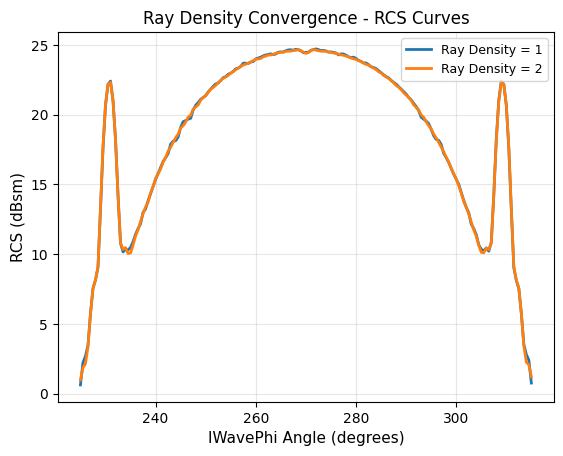

In [26]:
fig, ax = plt.subplots()
for i, (rd, rcs_curve, iwavephi) in enumerate(zip(ray_densities, all_rcs_ray, all_phi_ray)):
    ax.plot(iwavephi, rcs_curve, linewidth=2, label=f"Ray Density = {rd}")
ax.set_xlabel("IWavePhi Angle (degrees)", fontsize=11)
ax.set_ylabel("RCS (dBsm)", fontsize=11)
ax.set_title(f"Ray Density Convergence - RCS Curves", fontsize=12)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

### Plot 2: Ray Density - Average RCS

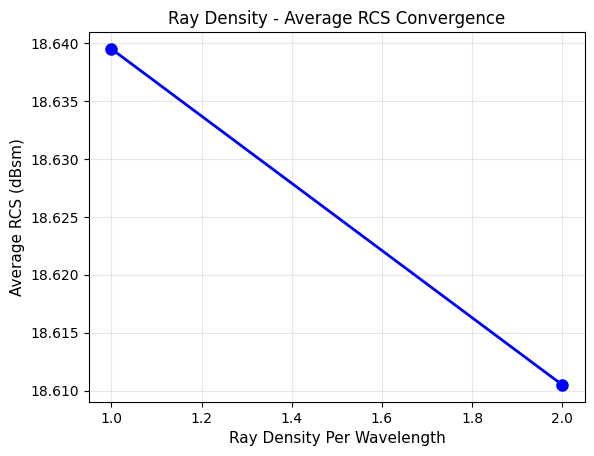

In [27]:
fig, ax = plt.subplots()
ax.plot(ray_densities, avg_rcs_ray, "bo-", linewidth=2, markersize=8)
ax.set_xlabel("Ray Density Per Wavelength", fontsize=11)
ax.set_ylabel("Average RCS (dBsm)", fontsize=11)
ax.set_title("Ray Density - Average RCS Convergence", fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

### Plot 3: Bounce Number - RCS Curves

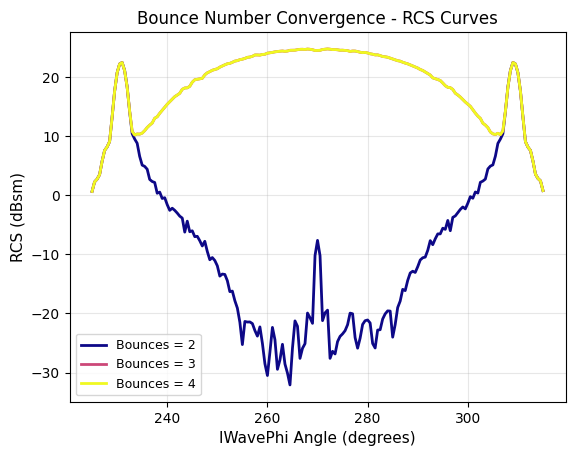

In [28]:
fig, ax = plt.subplots()
colors2 = plt.cm.plasma(np.linspace(0, 1, len(bounce_numbers)))
for i, (bn, rcs_curve, iwavephi) in enumerate(zip(bounce_numbers, all_rcs_bounce, all_phi_bounce)):
    ax.plot(iwavephi, rcs_curve, color=colors2[i], linewidth=2, label=f"Bounces = {bn}")
ax.set_xlabel("IWavePhi Angle (degrees)", fontsize=11)
ax.set_ylabel("RCS (dBsm)", fontsize=11)
ax.set_title(f"Bounce Number Convergence - RCS Curves", fontsize=12)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

### Plot 4: Bounce Number - Average RCS

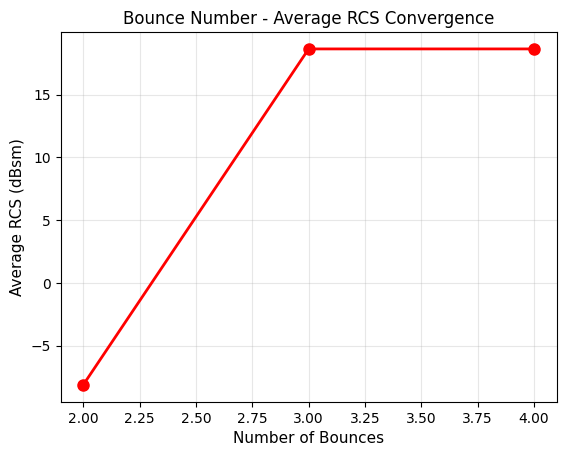

In [29]:
fig, ax = plt.subplots()
ax.plot(bounce_numbers, avg_rcs_bounce, "ro-", linewidth=2, markersize=8)
ax.set_xlabel("Number of Bounces", fontsize=11)
ax.set_ylabel("Average RCS (dBsm)", fontsize=11)
ax.set_title("Bounce Number - Average RCS Convergence", fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

## Advanced post-processing

For more advanced RCS analysis and visualization, you can use PyAEDT's ``get_rcs_data()`` method.
This method exports RCS simulation data into a standardized metadata format and returns
a ``MonostaticRCSExporter`` object for further processing.

### Using the radar explorer toolkit

For advanced RCS analysis and visualization capabilities, install the radar explorer toolkit:

```bash
pip install ansys-aedt-toolkits-radar-explorer
```

The radar explorer toolkit provides powerful features for RCS data analysis:

- **Interactive 3D RCS pattern visualization** with customizable viewing angles
- **Polar and Cartesian plot formats** for different analysis perspectives
- **Multi-frequency RCS comparison** to analyze frequency-dependent behavior
- **Export capabilities** for various formats (CSV, JSON, images)
- **Advanced filtering and data manipulation** tools
- **Statistical analysis** of RCS patterns

### Example: Visualizing RCS data with the toolkit

Here's a complete example showing how to export RCS data from HFSS and visualize it
using the radar explorer toolkit. For more examples, visit the
[radar explorer toolkit documentation](https://aedt.radar.explorer.toolkit.docs.pyansys.com/version/stable/examples/index.html).

```python
# Export RCS data using PyAEDT's get_rcs_data method
rcs_exporter = hfss.get_rcs_data()

# Import the radar explorer toolkit
from ansys.aedt.toolkits.radar_explorer.rcs_visualization import MonostaticRCSData, MonostaticRCSPlotter

# Load the RCS data
rcs_data = MonostaticRCSData(rcs_exporter.metadata_file)

# Create a plotter instance
plotter = MonostaticRCSPlotter(rcs_data)

plotter.plot_rcs()
plotter = plot_rcs_3d()
```

For more examples and detailed documentation, visit:
https://aedt.radar.explorer.toolkit.docs.pyansys.com/version/stable/examples/index.html

## Finish

### Save the project

In [30]:
hfss.save_project()
hfss.release_desktop()

PyAEDT INFO: Project trihedral_rcs Saved correctly


PyAEDT INFO: Desktop has been released and closed.


True

In [31]:
# Wait 3 seconds to allow AEDT to shut down before cleaning the temporary directory.
time.sleep(3)

## Clean up

All project files are saved in the folder ``temp_folder.name``. If you've run this example as a Jupyter notebook, you
can retrieve those project files. The following cell removes all temporary files, including the project folder.

In [32]:
temp_folder.cleanup()